In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import time


# Phase 1 -> fetch data with yfinance

In [2]:
# Stocks organized by sector - 200 Total (20 per sector)
STOCKS = {
    "IT": [
        "TCS.NS", "INFY.NS", "WIPRO.NS", "HCLTECH.NS", "TECHM.NS", 
        "LTIM.NS", "MPHASIS.NS", "COFORGE.NS", "PERSISTENT.NS", "LTTS.NS", 
        "KPITTECH.NS", "TATAELXSI.NS", "CYIENT.NS", "ZENSARTECH.NS", "SONATSOFTW.NS", 
        "BSOFT.NS", "INTELLECT.NS", "MASTEK.NS", "OFSS.NS", "TATACOMM.NS"
    ],
    "Banking": [
        "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS", "AXISBANK.NS", 
        "INDUSINDBK.NS", "BANKBARODA.NS", "PNB.NS", "CANBK.NS", "AUFINANCE.NS", 
        "IDFCFIRSTB.NS", "FEDERALBNK.NS", "BANDHANBNK.NS", "YESBANK.NS", "IDBI.NS", 
        "UNIONBANK.NS", "INDIANB.NS", "UCOBANK.NS", "CENTRALBK.NS", "PSB.NS"
    ],
    "Auto": [
        "MARUTI.NS", "TATAMOTORS.NS", "BAJAJ-AUTO.NS", "M&M.NS", "HEROMOTOCO.NS", 
        "EICHERMOT.NS", "TVSMOTOR.NS", "ASHOKLEY.NS", "BHARATFORG.NS", "BALKRISIND.NS", 
        "MRF.NS", "APOLLOTYRE.NS", "JKTYRE.NS", "CEATLTD.NS", "SONACOMS.NS", 
        "BOSCHLTD.NS", "MOTHERSON.NS", "ESCORTS.NS", "TUBEINVEST.NS", "EXIDEIND.NS"
    ],
    "Pharma": [
        "SUNPHARMA.NS", "DRREDDY.NS", "CIPLA.NS", "DIVISLAB.NS", "APOLLOHOSP.NS", 
        "MANKIND.NS", "TORNTPHARM.NS", "ZYDUSLIFE.NS", "SYNGENE.NS", "LUPIN.NS", 
        "AUROPHARMA.NS", "ALKEM.NS", "ABBOTINDIA.NS", "BIOCON.NS", "GLENMARK.NS", 
        "LAURUSLABS.NS", "IPCALAB.NS", "GRANULES.NS", "JBCHEPHARM.NS", "PFIZER.NS"
    ],
    "FMCG": [
        "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "BRITANNIA.NS", "DABUR.NS", 
        "GODREJCP.NS", "TATACONSUM.NS", "VBL.NS", "MARICO.NS", "COLPAL.NS", 
        "PGHL.NS", "UBL.NS", "MCDOWELL-N.NS", "BALRAMCHIN.NS", "RADICO.NS", 
        "EMAMILTD.NS", "JYOTHYLAB.NS", "BIKAJI.NS", "MRSBECTORS.NS", "HONASA.NS"
    ],
    "Metal": [
        "TATASTEEL.NS", "JSWSTEEL.NS", "HINDALCO.NS", "VEDL.NS", "SAIL.NS", 
        "JINDALSTEL.NS", "NMDC.NS", "HINDZINC.NS", "NATIONALUM.NS", "COALINDIA.NS", 
        "RATNAMANI.NS", "WELCORP.NS", "APLAPOLLO.NS", "JSL.NS", "GRAVITA.NS", 
        "KIRLOSENG.NS", "SMEL.NS", "MOIL.NS", "MAHSEAMLES.NS", "ISMTLTD.NS"
    ],
    "Energy": [
        "RELIANCE.NS", "ONGC.NS", "NTPC.NS", "POWERGRID.NS", "BPCL.NS", 
        "IOC.NS", "GAIL.NS", "ADANIGREEN.NS", "ADANIENSOL.NS", "ADANIPOWER.NS", 
        "TATAPOWER.NS", "JSWENERGY.NS", "NHPC.NS", "SJVN.NS", "IREDA.NS", 
        "PETRONET.NS", "OIL.NS", "GSPL.NS", "GUJGASLTD.NS", "IGL.NS"
    ],
    "Realty": [
        "DLF.NS", "GODREJPROP.NS", "OBEROIRLTY.NS", "PRESTIGE.NS", "BRIGADE.NS", 
        "LODHA.NS", "PHOENIXLTD.NS", "SOBHA.NS", "SUNTECK.NS", "MAHLIFE.NS", 
        "SIGNATURE.NS", "SWANENERGY.NS", "IBREALEST.NS", "KOLTEPATIL.NS", "PURVA.NS", 
        "ASHIANA.NS", "AJMERA.NS", "GANESHHOUC.NS", "MANINFRA.NS", "KEYCORP.NS"
    ],
    "Media": [
        "ZEEL.NS", "PVRINOX.NS", "SUNTV.NS", "HATHWAY.NS", "NETWORK18.NS", 
        "TV18BRDCST.NS", "SAREGAMA.NS", "NAZARA.NS", "DISHTV.NS", "DEN.NS", 
        "MUSICBROAD.NS", "ENIL.NS", "JAGRAN.NS", "DBCORP.NS", "NDTV.NS", 
        "TVTODAY.NS", "TIPSINDLTD.NS", "SHEMAROO.NS", "MPSLTD.NS", "SNDTRD.NS"
    ],
    "FinServ": [
        "BAJFINANCE.NS", "BAJAJFINSV.NS", "HDFCLIFE.NS", "SBILIFE.NS", "ICICIGI.NS", 
        "ICICIPRULI.NS", "CHOLAFIN.NS", "RECLTD.NS", "PFC.NS", "MUTHOOTFIN.NS", 
        "SHRIRAMFIN.NS", "M&MFIN.NS", "L&TFH.NS", "LICHSGFIN.NS", "CANFINHOME.NS", 
        "MANAPPURAM.NS", "POONAWALLA.NS", "ANGELONE.NS", "MOTILALOFS.NS", "GEOJITFSL.NS"
    ],
}

In [3]:
sector_dfs = {}

for sector, tickers in STOCKS.items():
    print(f"Fetching {sector}...")
    sector_dfs[sector] = yf.download(
        tickers,
        period="3y",
        auto_adjust=True,
        progress=False
    )
    print(f"fetched {sector}. shape: {sector_dfs[sector].shape}")
    time.sleep(1)

print("Done!")

Fetching IT...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
$LTIM.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['LTIM.NS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


fetched IT. shape: (741, 101)
Fetching Banking...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: AUFINANCE.NS"}}}
$AUFINANCE.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['AUFINANCE.NS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


fetched Banking. shape: (741, 101)
Fetching Auto...


...

fetched Realty. shape: (741, 103)
Fetching Media...


$MUSICBROAD.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$SNDTRD.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$TIPSINDLTD.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
$TV18BRDCST.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

4 Failed downloads:
['MUSICBROAD.NS', 'SNDTRD.NS', 'TIPSINDLTD.NS', 'TV18BRDCST.NS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


fetched Media. shape: (741, 104)
Fetching FinServ...


$L&TFH.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['L&TFH.NS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


fetched FinServ. shape: (741, 101)
Done!


In [4]:
sector_dfs.keys()

dict_keys(['IT', 'Banking', 'Auto', 'Pharma', 'FMCG', 'Metal', 'Energy', 'Realty', 'Media', 'FinServ'])

In [5]:
sector_dfs["IT"]           

Price      Adj Close       Close                                         \
Ticker       LTIM.NS    BSOFT.NS   COFORGE.NS    CYIENT.NS   HCLTECH.NS   
Date                                                                      
2023-05-12       NaN  295.984558   791.328674  1139.282593   974.740417   
2023-05-15       NaN  297.043335   800.170288  1198.222900   978.521729   
2023-05-16       NaN  316.053711   814.251221  1159.164917   970.469421   
2023-05-17       NaN  309.027069   816.188049  1212.969849   956.099609   
2023-05-18       NaN  307.053864   814.667725  1213.158325   960.859802   
...              ...         ...          ...          ...          ...   
2026-05-06       NaN  372.500000  1280.400024   900.750000  1189.099976   
2026-05-07       NaN  362.200012  1285.300049   894.400024  1183.400024   
2026-05-08       NaN  362.149994  1368.099976   904.700012  1198.400024   
2026-05-11       NaN  355.899994  1375.199951   919.750000  1194.900024   
2026-05-12       NaN  331.600006  1320.400024   903.450012  1145.800049   

Price                                                                  ...  \
Ticker          INFY.NS INTELLECT.NS KPITTECH.NS LTIM.NS      LTTS.NS  ...   
Date                                                                   ...   
2023-05-12  1142.006958   524.418457  885.098694     NaN  3682.341309  ...   
2023-05-15  1154.067261   535.472351  907.013245     NaN  3723.726807  ...   
2023-05-16  1159.524170   533.103699  913.218201     NaN  3716.435059  ...   
2023-05-17  1143.566040   539.173401  919.078430     NaN  3695.718018  ...   
2023-05-18  1142.740601   544.009521  926.859375     NaN  3713.054688  ...   
...                 ...          ...         ...     ...          ...  ...   
2026-05-06  1167.199951   784.400024  748.599976     NaN  3804.800049  ...   
2026-05-07  1162.699951   782.150024  722.650024     NaN  3772.899902  ...   
2026-05-08  1179.199951   806.799988  729.150024     NaN  3802.600098  ...   
2026-05-11  1177.000000   760.349976  733.450012     NaN  3788.399902  ...   
2026-05-12  1140.300049   723.549988  712.049988     NaN  3603.699951  ...   

Price          Volume                                                  \
Ticker     MPHASIS.NS OFSS.NS PERSISTENT.NS SONATSOFTW.NS TATACOMM.NS   
Date                                                                    
2023-05-12     276950   61128        419216        683202      200541   
2023-05-15     208388   98438        311284       2769046      466435   
2023-05-16     299566   68414        660646       4996546      313277   
2023-05-17     296129   66501        713662       2816002      285053   
2023-05-18     244990   48639        360724       1369096      180190   
...               ...     ...           ...           ...         ...   
2026-05-06     416557  250721        799823        713333      456933   
2026-05-07     592910  310150        512165        717080      223943   
2026-05-08     271921  198264        633097      29635371      369396   
2026-05-11     214275  126412        339705       3163099      158224   
2026-05-12     887817  165787        697611       2710079      257072   

Price                                                              
Ticker     TATAELXSI.NS   TCS.NS TECHM.NS  WIPRO.NS ZENSARTECH.NS  
Date                                                               
2023-05-12       142267  1027479  1140016   4580358      14775091  
2023-05-15       177522  1150390  2122222   5089694      19401965  
2023-05-16       154662   986306  1343911   4059352       9594900  
2023-05-17       115618  1588815  2803566   5376102       2433055  
2023-05-18       115117  1369364   909923   4237016       2753263  
...                 ...      ...      ...       ...           ...  
2026-05-06       287870  3147628   877900  13166683        451589  
2026-05-07       182289  5829594  1147147  19303572        495666  
2026-05-08       204444  3792199  1360644  15970687        808063  
2026-05-11       

In [6]:
sector_dfs["IT"].xs("TCS.NS", axis=1, level=1)

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-05-12,3011.274902,3025.713673,2998.123579,3015.735166,1027479
2023-05-15,2993.571533,3027.553291,2987.409790,3020.195932,1150390
2023-05-16,2996.422363,3021.115590,2989.340950,2994.629052,986306
2023-05-17,2950.945068,3016.517584,2941.334562,2994.399476,1588815
2023-05-18,2942.805664,2969.567922,2938.345175,2966.808912,1369364
...,...,...,...,...,...
2026-05-06,2435.399902,2471.000000,2406.500000,2441.899902,3147628
2026-05-07,2401.399902,2439.699951,2398.000000,2438.199951,5829594
2026-05-08,2394.399902,2407.000000,2375.100098,2398.000000,3792199


# Phase 2 -> clean data, save to CSV

In [7]:
def reshape(sector_df, sector_name):
    df = sector_df.stack(level=1).reset_index()
    df.columns.name = None   # clears it
    df = df.rename(columns={"level_1": "Ticker"})
    df["Sector"] = sector_name
    return df

master_df = pd.concat(
    [reshape(df, sector) for sector, df in sector_dfs.items()],
    ignore_index=True
)

In [8]:
master_df[master_df["Ticker"] == "TCS.NS"]

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Sector
16,2023-05-12,TCS.NS,NaN,3011.274902,3025.713673,2998.123579,3015.735166,1027479.0,IT
36,2023-05-15,TCS.NS,NaN,2993.571533,3027.553291,2987.409790,3020.195932,1150390.0,IT
56,2023-05-16,TCS.NS,NaN,2996.422363,3021.115590,2989.340950,2994.629052,986306.0,IT
76,2023-05-17,TCS.NS,NaN,2950.945068,3016.517584,2941.334562,2994.399476,1588815.0,IT
96,2023-05-18,TCS.NS,NaN,2942.805664,2969.567922,2938.345175,2966.808912,1369364.0,IT
...,...,...,...,...,...,...,...,...,...
14736,2026-05-06,TCS.NS,NaN,2435.399902,2471.000000,2406.500000,2441.899902,3147628.0,IT
14756,2026-05-07,TCS.NS,NaN,2401.399902,2439.699951,2398.000000,2438.199951,5829594.0,IT
14776,2026-05-08,TCS.NS,NaN,2394.399902,2407.000000,2375.100098,2398.000000,3792199.0,IT
14796,2026-05-11,TCS.NS,NaN,2392.899902,2415.000000,2371.000000,2371.000000,1975188.0,IT


In [9]:
print(master_df.shape)
print(master_df.dtypes)
print(master_df.isnull().sum())
print(master_df.duplicated().sum())

(148200, 9)
Date         datetime64[s]
Ticker                 str
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume             float64
Sector                 str
dtype: object
Date              0
Ticker            0
Adj Close    148200
Close         12346
High          12346
Low           12346
Open          12346
Volume        12346
Sector            0
dtype: int64
0


In [10]:
print(master_df.dtypes)

Date         datetime64[s]
Ticker                 str
Adj Close          float64
Close              float64
High               float64
Low                float64
Open               float64
Volume             float64
Sector                 str
dtype: object


In [11]:
# see which tickers have the most missing data
missing_by_ticker = master_df[master_df['Close'].isnull()].groupby('Ticker').size().sort_values(ascending=False)
missing_by_ticker

Ticker
AUFINANCE.NS     741
ISMTLTD.NS       741
GANESHHOUC.NS    741
LTIM.NS          741
MCDOWELL-N.NS    741
L&TFH.NS         741
KEYCORP.NS       741
SMEL.NS          741
TATAMOTORS.NS    741
MUSICBROAD.NS    741
TUBEINVEST.NS    741
TIPSINDLTD.NS    741
SNDTRD.NS        741
SWANENERGY.NS    741
TV18BRDCST.NS    741
MRSBECTORS.NS    741
IREDA.NS         136
HONASA.NS        123
SIGNATURE.NS      97
ADANIENSOL.NS     72
PVRINOX.NS        21
DEN.NS             2
GSPL.NS            2
MPSLTD.NS          2
SHEMAROO.NS        2
PHOENIXLTD.NS      2
PGHL.NS            2
KOLTEPATIL.NS      2
DIVISLAB.NS        1
GEOJITFSL.NS       1
ENIL.NS            1
BOSCHLTD.NS        1
DBCORP.NS          1
BHARATFORG.NS      1
ALKEM.NS           1
AUROPHARMA.NS      1
BALKRISIND.NS      1
BIKAJI.NS          1
GRANULES.NS        1
JAGRAN.NS          1
IPCALAB.NS         1
GUJGASLTD.NS       1
IBREALEST.NS       1
MANINFRA.NS        1
KIRLOSENG.NS       1
MRF.NS             1
MANKIND.NS         1
OBEROI

In [12]:
master_df[master_df['Close'].isnull()]

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Sector
0,2023-05-12,LTIM.NS,NaN,NaN,NaN,NaN,NaN,NaN,IT
20,2023-05-15,LTIM.NS,NaN,NaN,NaN,NaN,NaN,NaN,IT
40,2023-05-16,LTIM.NS,NaN,NaN,NaN,NaN,NaN,NaN,IT
60,2023-05-17,LTIM.NS,NaN,NaN,NaN,NaN,NaN,NaN,IT
80,2023-05-18,LTIM.NS,NaN,NaN,NaN,NaN,NaN,NaN,IT
...,...,...,...,...,...,...,...,...,...
148100,2026-05-06,L&TFH.NS,NaN,NaN,NaN,NaN,NaN,NaN,FinServ
148120,2026-05-07,L&TFH.NS,NaN,NaN,NaN,NaN,NaN,NaN,FinServ
148140,2026-05-08,L&TFH.NS,NaN,NaN,NaN,NaN,NaN,NaN,FinServ
148160,2026-05-11,L&TFH.NS,NaN,NaN,NaN,NaN,NaN,NaN,FinServ


In [13]:
# Drop tickers with too much missing data (>30 days threshold)
tickers_to_drop = missing_by_ticker[missing_by_ticker > 30].index.tolist()
print("Dropping:", tickers_to_drop)

master_df = master_df[~master_df["Ticker"].isin(tickers_to_drop)]
master_df["Ticker"].unique()

Dropping: ['AUFINANCE.NS', 'ISMTLTD.NS', 'GANESHHOUC.NS', 'LTIM.NS', 'MCDOWELL-N.NS', 'L&TFH.NS', 'KEYCORP.NS', 'SMEL.NS', 'TATAMOTORS.NS', 'MUSICBROAD.NS', 'TUBEINVEST.NS', 'TIPSINDLTD.NS', 'SNDTRD.NS', 'SWANENERGY.NS', 'TV18BRDCST.NS', 'MRSBECTORS.NS', 'IREDA.NS', 'HONASA.NS', 'SIGNATURE.NS', 'ADANIENSOL.NS']


<StringArray>
[     'BSOFT.NS',    'COFORGE.NS',     'CYIENT.NS',    'HCLTECH.NS',
       'INFY.NS',  'INTELLECT.NS',   'KPITTECH.NS',       'LTTS.NS',
     'MASTEK.NS',    'MPHASIS.NS',
 ...
  'LICHSGFIN.NS',     'M&MFIN.NS', 'MANAPPURAM.NS', 'MOTILALOFS.NS',
 'MUTHOOTFIN.NS',        'PFC.NS', 'POONAWALLA.NS',     'RECLTD.NS',
    'SBILIFE.NS', 'SHRIRAMFIN.NS']
Length: 180, dtype: str

In [14]:
# Forward fill remaining gaps (per ticker, not across tickers)

master_df = master_df.sort_values(["Ticker", "Date"])
master_df["Close"]  = master_df.groupby("Ticker")["Close"].ffill()
master_df["Open"]   = master_df.groupby("Ticker")["Open"].ffill()
master_df["High"]   = master_df.groupby("Ticker")["High"].ffill()
master_df["Low"]    = master_df.groupby("Ticker")["Low"].ffill()
master_df["Volume"] = master_df.groupby("Ticker")["Volume"].ffill()


In [15]:
# Verify no NaNs remain
print(master_df.isnull().sum())
print(master_df.shape)


Date              0
Ticker            0
Adj Close    133380
Close             0
High              0
Low               0
Open              0
Volume            0
Sector            0
dtype: int64
(133380, 9)


In [16]:
print(master_df.columns.tolist())

['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Sector']


In [17]:
print(master_df.index.name)

None


In [18]:
print(master_df.shape)
print(master_df["Ticker"].nunique())
print(master_df["Sector"].unique())
print(master_df.head())

(133380, 9)
180
<StringArray>
[ 'Pharma',  'Energy',  'Realty', 'FinServ',   'Metal',    'Auto', 'Banking',
    'FMCG',      'IT',   'Media']
Length: 10, dtype: str
            Date         Ticker  Adj Close         Close          High  \
44460 2023-05-12  ABBOTINDIA.NS        NaN  20356.218750  20646.372204   
44480 2023-05-15  ABBOTINDIA.NS        NaN  20354.876953  20625.278088   
44500 2023-05-16  ABBOTINDIA.NS        NaN  20322.466797  20468.743056   
44520 2023-05-17  ABBOTINDIA.NS        NaN  20342.890625  20462.221154   
44540 2023-05-18  ABBOTINDIA.NS        NaN  20108.015625  20475.644585   

                Low          Open   Volume  Sector  
44460  20265.701120  20391.312989  15506.0  Pharma  
44480  20308.851228  20422.956672  10716.0  Pharma  
44500  20205.389231  20423.867224   8737.0  Pharma  
44520  20208.169495  20329.945890  10602.0  Pharma  
44540  20071.050468  20452.680416   7346.0  Pharma  


In [19]:
# The index is still showing old numbers (11145, 11150...) from before. Clean that up
master_df = master_df.reset_index(drop=True)

In [20]:
def cap_col(series):
    Q1 = series.quantile(0.01)
    Q3 = series.quantile(0.99)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower=lower, upper=upper)

prev_rows = master_df.shape[0]

for col in ["Close", "Open", "High", "Low", "Volume"]:
    master_df[col] = master_df.groupby("Ticker")[col].transform(cap_col)

print("Outlier capping done")

if(master_df.shape[0]==prev_rows):
    print("Nothing Clipped!")
else:
    print(f"{prev_rows-master_df.shape[0]} rows clipped!")

Outlier capping done
Nothing Clipped!


In [21]:
master_df.describe()

,Date,Adj Close,Close,High,Low,Open,Volume
count,133380,0.0,133380.000000,133380.000000,133380.000000,133380.000000,1.333800e+05
mean,2024-11-09 19:18:13,NaN,2253.717556,2281.518240,2227.877839,2256.211066,6.423432e+06
min,2023-05-12 00:00:00,NaN,1.840000,2.030000,1.820000,2.020000,0.000000e+00
25%,2024-02-09 00:00:00,NaN,255.205708,259.483220,251.433990,255.499862,3.576005e+05
50%,2024-11-11 00:00:00,NaN,628.289520,637.455669,619.308692,628.610510,1.262800e+06
75%,2025-08-08 00:00:00,NaN,1558.586182,1580.014305,1537.568161,1559.746862,5.674756e+06
max,2026-05-12 00:00:00,NaN,162288.578125,163593.537167,160278.657659,161973.590589,9.853108e+08
std,NaN,NaN,10147.066911,10256.698821,10051.028818,10163.089579,1.978378e+07


In [22]:
# check zero volume rows
zero_vol = master_df[master_df["Volume"] == 0]
print(zero_vol.shape)
print(zero_vol.groupby("Ticker").size().sort_values(ascending=False).head())

(525, 9)
Ticker
IBREALEST.NS     15
BAJAJ-AUTO.NS     4
ANGELONE.NS       4
NAZARA.NS         4
POONAWALLA.NS     4
dtype: int64


In [23]:
# see which dates have zero volume
print(zero_vol["Date"].value_counts().sort_values(ascending=False))

Date
2025-03-18    178
2026-05-01    163
2026-01-15    156
2024-01-15     12
2023-05-24      2
2025-09-08      2
2026-04-10      1
2026-04-15      1
2026-04-16      1
2026-04-17      1
2026-04-21      1
2026-04-22      1
2026-04-23      1
2026-04-24      1
2026-04-28      1
2026-04-29      1
2026-04-30      1
2026-05-05      1
Name: count, dtype: int64


In [24]:
# We see 3-4 dates with 40+ tickers each all showing zero volume on the same day. That confirms it's a market-wide event, not individual stock issues.
# replace zero volume with NaN then forward fill
master_df["Volume"] = master_df["Volume"].replace(0, float("nan"))
master_df["Volume"] = master_df.groupby("Ticker")["Volume"].ffill()

print(master_df[master_df["Volume"] == 0].shape)

(0, 9)


In [25]:
# High should always be >= Close, Open, Low
# Low should always be <= Close, Open, High
# if not, that row has corrupt price data

bad_rows = master_df[
    (master_df["High"] < master_df["Close"]) |
    (master_df["High"] < master_df["Open"])  |
    (master_df["Low"]  > master_df["Close"]) |
    (master_df["Low"]  > master_df["Open"])
]

print(f"Corrupt OHLC rows: {bad_rows.shape[0]}")

Corrupt OHLC rows: 0


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")  # nicer default styling

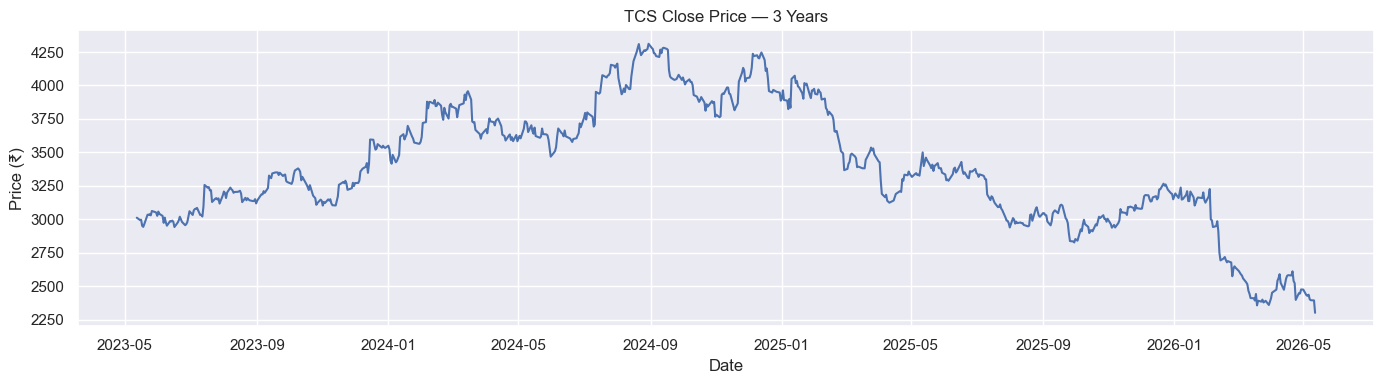

In [27]:
tcs = master_df[master_df["Ticker"] == "TCS.NS"].set_index("Date")

plt.figure(figsize=(14, 4))
plt.plot(tcs["Close"])
plt.title("TCS Close Price — 3 Years")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()


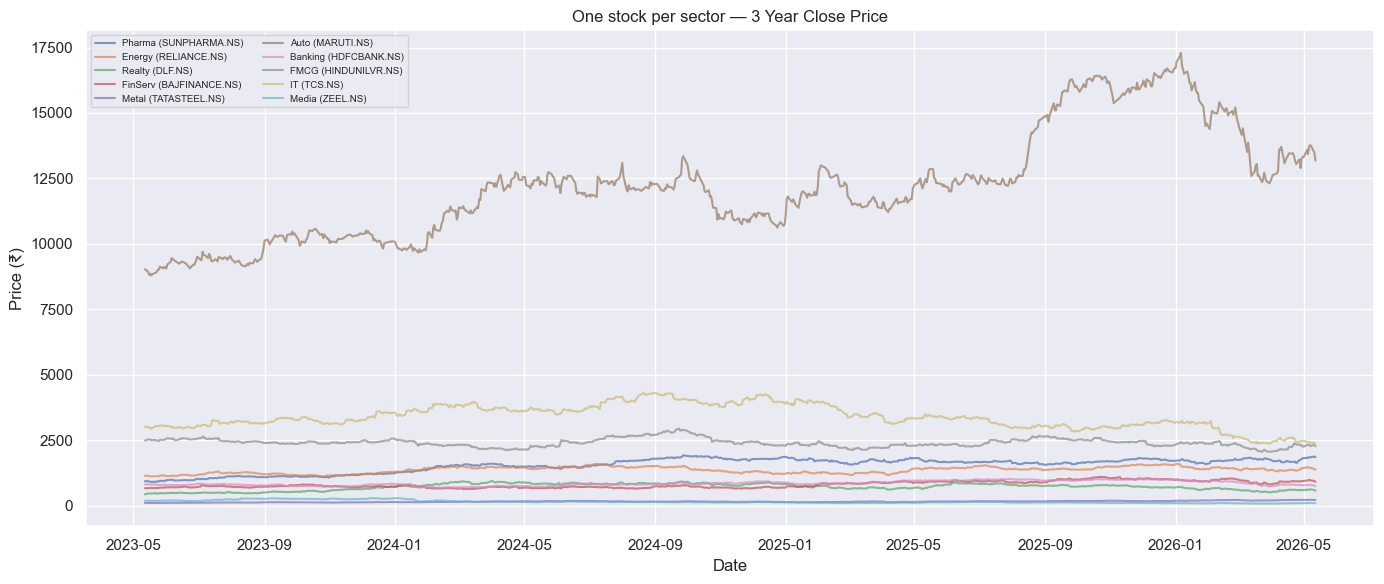

In [28]:
plt.figure(figsize=(14, 6))

for sector in master_df["Sector"].unique():
    # take one representative ticker per sector
    # ticker = master_df[master_df["Sector"] == sector]["Ticker"].iloc[0]
    ticker = STOCKS[sector][0]
    df_t = master_df[master_df["Ticker"] == ticker].set_index("Date")
    plt.plot(df_t["Close"], label=f"{sector} ({ticker})", alpha=0.7)

plt.title("One stock per sector — 3 Year Close Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

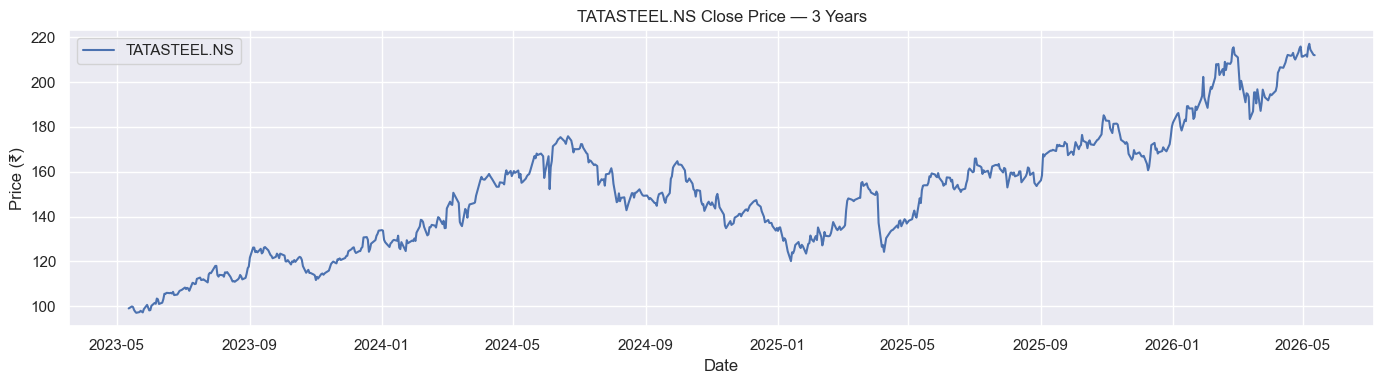

In [29]:
# The Metal sector ticker looks flatline....lets check that.
ticker = STOCKS['Metal'][0]

# If this graph is not flat, then the reason Metal looked flat in the sector overlay chart is a scale problem, not bad data.
plt.figure(figsize=(14, 4))

df_t = master_df[master_df["Ticker"] == ticker].set_index("Date")

plt.plot(df_t["Close"], label=ticker)
plt.title(f"{ticker} Close Price — 3 Years")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.tight_layout()
plt.show()

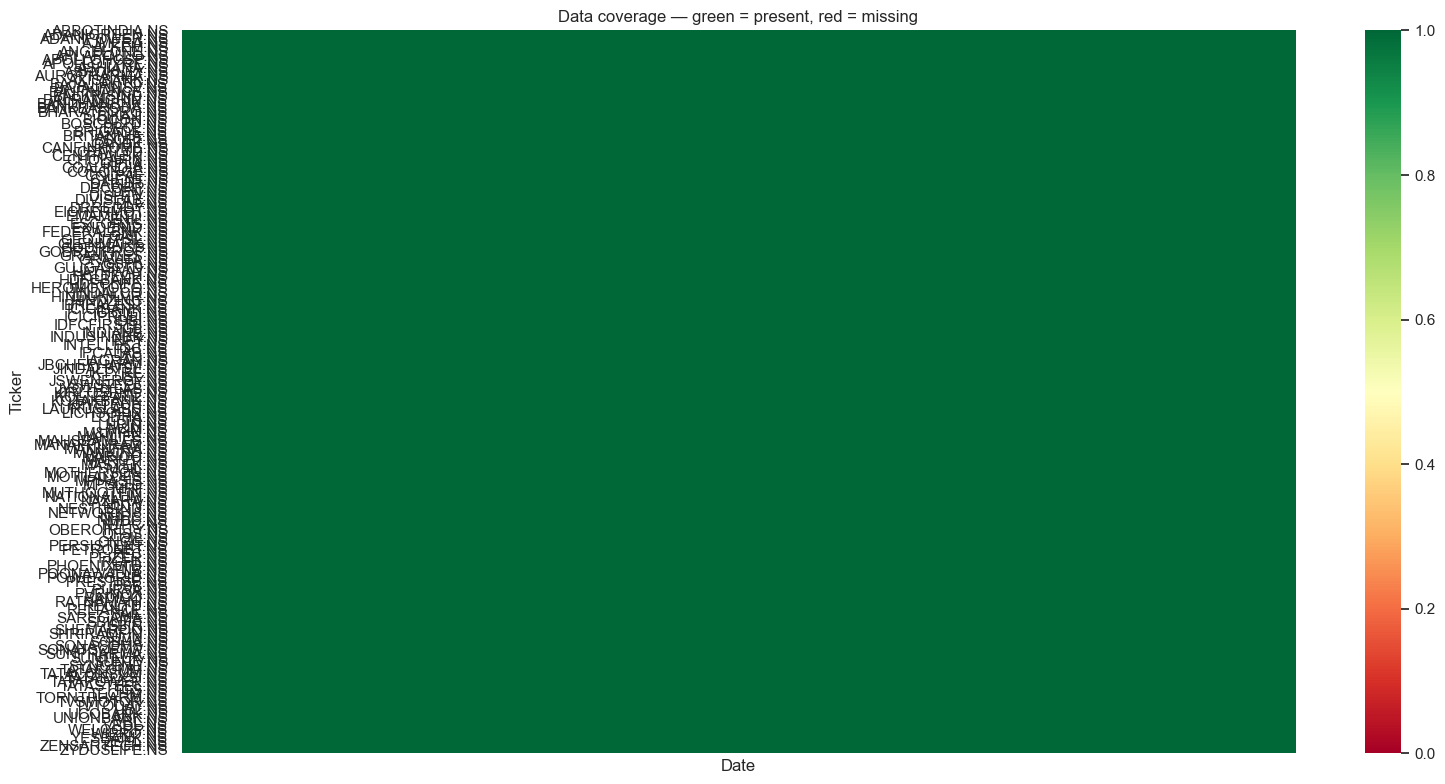

In [30]:
# Lets check if Ticker Volume has a long gap of missing data we might have missed

pivot = master_df.pivot_table(index="Date", columns="Ticker", values="Close")
coverage = pivot.notnull().astype(int)

plt.figure(figsize=(16, 8))
sns.heatmap(
    coverage.T,
    cmap="RdYlGn",        # red = missing, green = present — much more contrast
    cbar=True,
    xticklabels=False,
    yticklabels=True,
    vmin=0,               # force 0 = red even if no missing data exists
    vmax=1
)
plt.title("Data coverage — green = present, red = missing")
plt.tight_layout()
plt.show()

In [31]:
# Data is completely clean. Let's save it now:
master_df.to_csv("master_clean.csv", index=False)
print("Saved!")
print(master_df.shape)
print(master_df.head())

Saved!
(133380, 9)
        Date         Ticker  Adj Close         Close          High  \
0 2023-05-12  ABBOTINDIA.NS        NaN  20356.218750  20646.372204   
1 2023-05-15  ABBOTINDIA.NS        NaN  20354.876953  20625.278088   
2 2023-05-16  ABBOTINDIA.NS        NaN  20322.466797  20468.743056   
3 2023-05-17  ABBOTINDIA.NS        NaN  20342.890625  20462.221154   
4 2023-05-18  ABBOTINDIA.NS        NaN  20108.015625  20475.644585   

            Low          Open   Volume  Sector  
0  20265.701120  20391.312989  15506.0  Pharma  
1  20308.851228  20422.956672  10716.0  Pharma  
2  20205.389231  20423.867224   8737.0  Pharma  
3  20208.169495  20329.945890  10602.0  Pharma  
4  20071.050468  20452.680416   7346.0  Pharma  


# Phase 3 -> analysis (returns, volatility, correlations)

### How much did this stock gain or lose today?

In [32]:
# Daily returns per ticker
# pct_change() computes (today - yesterday) / yesterday
# groupby ensures we don't compute return across ticker boundaries

master_df = master_df.sort_values(["Ticker", "Date"])
master_df["Daily_Return"] = (
    master_df
    .groupby("Ticker")["Close"]
    .pct_change()
)



In [33]:
# 30 day rolling volatility
# for each day, std of the last 30 daily returns
# min_periods=10 means we need at least 10 days of data before computing
# (avoids garbage values at the very start of each ticker's history)

master_df["Volatility_30d"] = (
    master_df
    .groupby("Ticker")["Daily_Return"]
    .transform(lambda x: x.rolling(30, min_periods=10).std())
)



In [34]:
print(master_df[["Date", "Ticker", "Sector", "Close", "Daily_Return", "Volatility_30d"]].head(20))
print(master_df.isnull().sum())


         Date         Ticker  Sector         Close  Daily_Return  \
0  2023-05-12  ABBOTINDIA.NS  Pharma  20356.218750           NaN   
1  2023-05-15  ABBOTINDIA.NS  Pharma  20354.876953     -0.000066   
2  2023-05-16  ABBOTINDIA.NS  Pharma  20322.466797     -0.001592   
3  2023-05-17  ABBOTINDIA.NS  Pharma  20342.890625      0.001005   
4  2023-05-18  ABBOTINDIA.NS  Pharma  20108.015625     -0.011546   
5  2023-05-19  ABBOTINDIA.NS  Pharma  20038.880859     -0.003438   
6  2023-05-22  ABBOTINDIA.NS  Pharma  20494.007812      0.022712   
7  2023-05-23  ABBOTINDIA.NS  Pharma  20623.457031      0.006316   
8  2023-05-24  ABBOTINDIA.NS  Pharma  20586.921875     -0.001772   
9  2023-05-25  ABBOTINDIA.NS  Pharma  20942.568359      0.017275   
10 2023-05-26  ABBOTINDIA.NS  Pharma  21000.626953      0.002772   
11 2023-05-29  ABBOTINDIA.NS  Pharma  20993.292969     -0.000349   
12 2023-05-30  ABBOTINDIA.NS  Pharma  21147.478516      0.007345   
13 2023-05-31  ABBOTINDIA.NS  Pharma  20843.8046

In [35]:
'''
Output looks perfect.
Daily_Return NaN -> 180 NaNs = exactly right. 180 tickers × 1 NaN each (first row of every ticker has no previous day to compare against).
Volatility_30d NaN -> 1800 NaNs = exactly right. 180 tickers × 10 NaNs each. That's the rolling window min 10.
'''
print(master_df['Adj Close'].count())

0


In [36]:
# Adj Close has all NaNs. This is a new column yfinance added that we never cleaned. Lets just drop it.
master_df = master_df.drop(columns=["Adj Close"], errors="ignore")
print(master_df.columns.tolist())
print(master_df.isnull().sum())


['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume', 'Sector', 'Daily_Return', 'Volatility_30d']
Date                 0
Ticker               0
Close                0
High                 0
Low                  0
Open                 0
Volume               0
Sector               0
Daily_Return       180
Volatility_30d    1800
dtype: int64


In [37]:
# Perfect clean dataset, only the expected NaNs remaining. Saving the updated CSV
master_df.to_csv("master_clean.csv", index=False)
print("Saved!")

Saved!


### Which sectors gave the best returns over 3 years? 

In [38]:
# cumulative return per ticker over the full 3 year window
cum_returns = (
    master_df
    .groupby(["Ticker", "Sector"])["Daily_Return"]
    .apply(lambda x: (1 + x.dropna()).prod() - 1)  # multiply all (1+r) together
    .reset_index()
)
cum_returns.columns = ["Ticker", "Sector", "Cumulative_Return"]


In [39]:
# sector level — average cumulative return across all tickers in that sector
sector_returns = (
    cum_returns
    .groupby("Sector")["Cumulative_Return"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print(sector_returns)


    Sector  Cumulative_Return
0    Metal           1.622206
1   Pharma           1.081330
2  FinServ           0.954626
3     Auto           0.908758
4   Energy           0.887933
5   Realty           0.777551
6  Banking           0.526079
7     FMCG           0.372880
8       IT           0.233651
9    Media          -0.013456


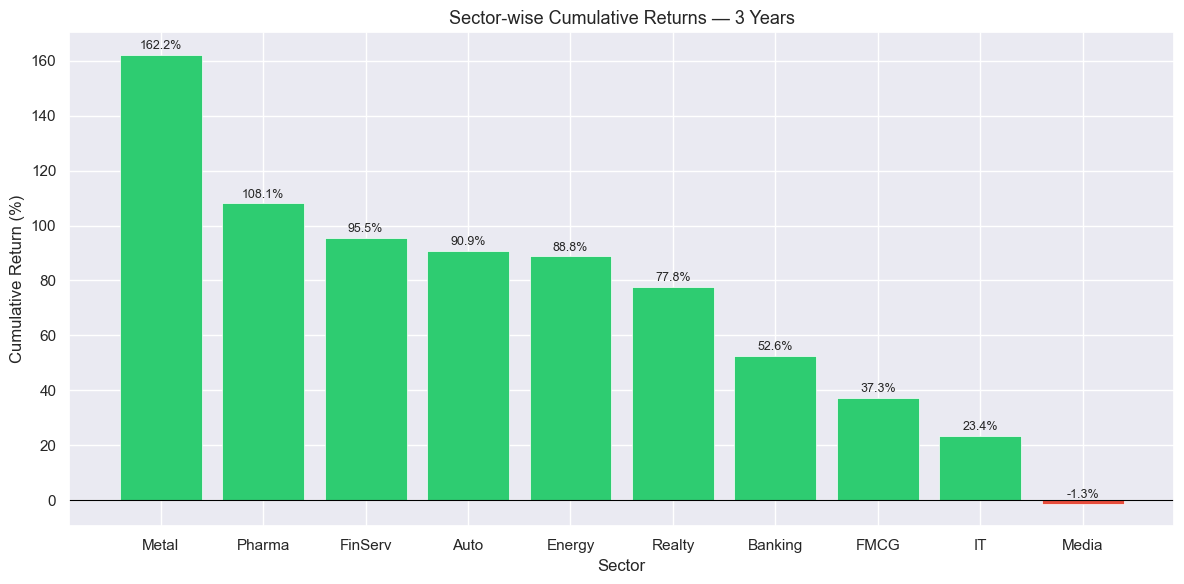

In [40]:
plt.figure(figsize=(12, 6))

colors = ["#2ecc71" if x > 0 else "#e74c3c" for x in sector_returns["Cumulative_Return"]]

bars = plt.bar(
    sector_returns["Sector"],
    sector_returns["Cumulative_Return"] * 100,  
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

# add value labels on top of each bar
for bar, val in zip(bars, sector_returns["Cumulative_Return"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        bar.get_height() + 1,                
        f"{val*100:.1f}%",                   
        ha="center", va="bottom", fontsize=9
    )

plt.axhline(y=0, color="black", linewidth=0.8)  # zero line
plt.title("Sector-wise Cumulative Returns — 3 Years", fontsize=13)
plt.xlabel("Sector")
plt.ylabel("Cumulative Return (%)")
plt.tight_layout()
plt.show()

In [41]:
# Average daily return per sector per date

sector_daily = (
    master_df
    .groupby(["Date", "Sector"])["Daily_Return"]
    .mean()  # average return across all tickers in that sector on that date
    .reset_index()
)

# Compute cumulative return per sector over time
# sort by date first so cumprod goes forward in time
sector_daily = sector_daily.sort_values(["Sector", "Date"])

sector_daily["Cumulative_Return"] = (
    sector_daily
    .groupby("Sector")["Daily_Return"]
    .transform(lambda x: (1 + x).cumprod() - 1)
)

# Convert to percentage for readability
sector_daily["Cumulative_Return_Pct"] = sector_daily["Cumulative_Return"] * 100

print(sector_daily.head(20))
print(sector_daily.shape)

          Date Sector  Daily_Return  Cumulative_Return  Cumulative_Return_Pct
0   2023-05-12   Auto           NaN                NaN                    NaN
10  2023-05-15   Auto      0.002795           0.002795               0.279536
20  2023-05-16   Auto      0.001538           0.004338               0.433757
30  2023-05-17   Auto      0.005442           0.009803               0.980284
40  2023-05-18   Auto     -0.009601           0.000108               0.010807
50  2023-05-19   Auto     -0.002920          -0.002812              -0.281180
60  2023-05-22   Auto      0.005397           0.002570               0.257027
70  2023-05-23   Auto      0.011198           0.013797               1.379688
80  2023-05-24   Auto      0.003841           0.017691               1.769062
90  2023-05-25   Auto      0.005975           0.023772               2.377150
100 2023-05-26   Auto      0.004928           0.028817               2.881661
110 2023-05-29   Auto     -0.003776           0.024932          

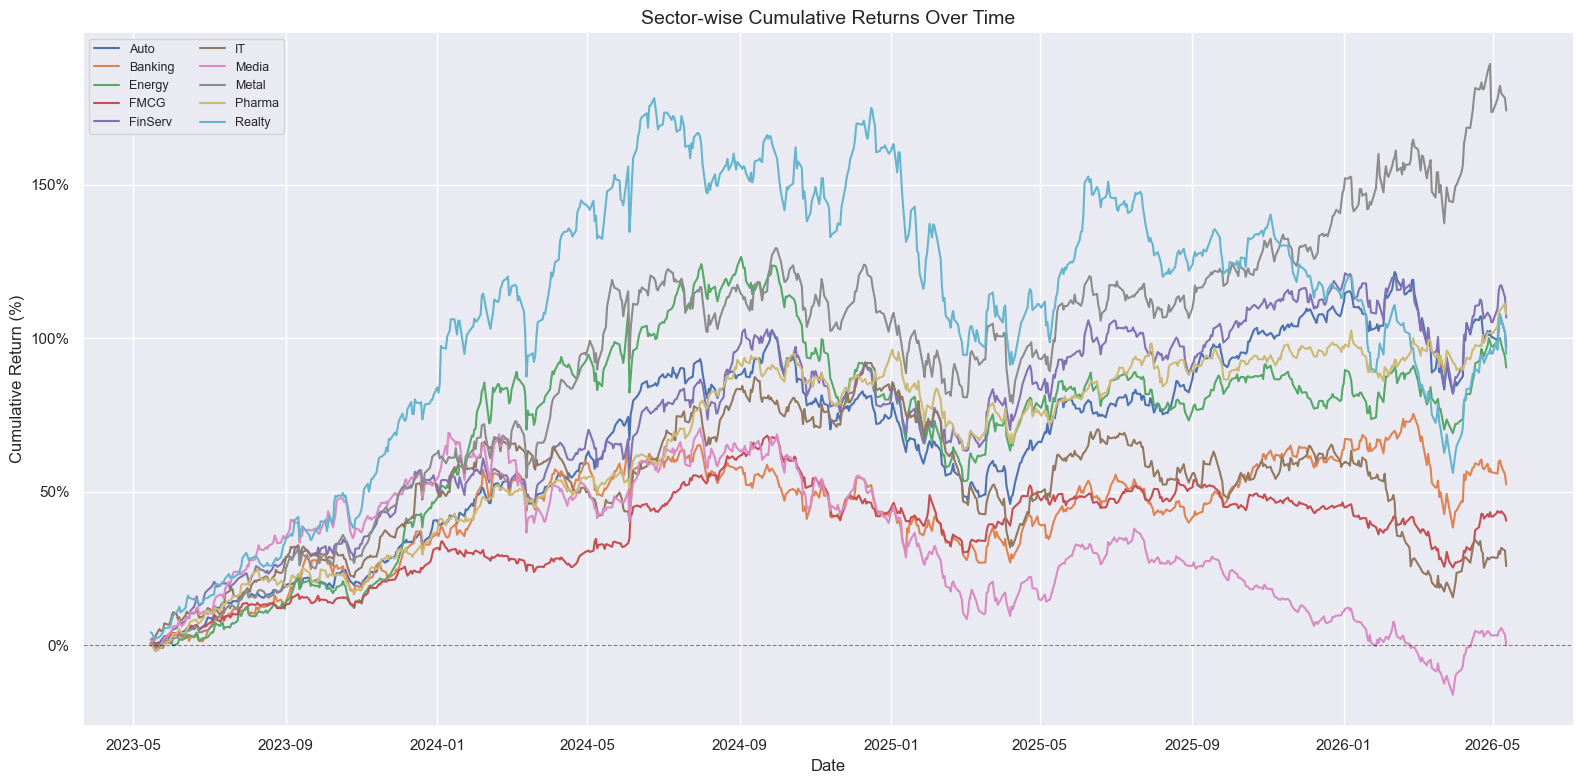

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(16, 8))

# plot one line per sector
for sector in sector_daily["Sector"].unique():
    data = sector_daily[sector_daily["Sector"] == sector]
    ax.plot(
        data["Date"],
        data["Cumulative_Return_Pct"],
        label=sector,
        linewidth=1.5
    )

# zero reference line — anything below this lost money
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# format y axis as percentage
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))

ax.set_title("Sector-wise Cumulative Returns Over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(loc="upper left", fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

In [43]:
# average 30-day rolling volatility per sector per date
sector_vol = (
    master_df
    .groupby(["Date", "Sector"])["Volatility_30d"]
    .mean()
    .reset_index()
)

# overall volatility per sector — single number summary
sector_vol_summary = (
    master_df
    .groupby("Sector")["Volatility_30d"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
sector_vol_summary.columns = ["Sector", "Avg_Volatility"]


In [44]:

# annualise the volatility
# daily volatility × sqrt(252) = annual volatility
# 252 = trading days in a year (not 365 — markets are closed weekends/holidays)
# sqrt because volatility scales with square root of time, not linearly
sector_vol_summary["Ann_Volatility"] = sector_vol_summary["Avg_Volatility"] * np.sqrt(252)

print(sector_vol_summary)

    Sector  Avg_Volatility  Ann_Volatility
0    Media        0.024832        0.394200
1   Realty        0.024660        0.391463
2    Metal        0.021626        0.343297
3  FinServ        0.020522        0.325770
4   Energy        0.019807        0.314433
5       IT        0.019622        0.311483
6  Banking        0.019101        0.303223
7     Auto        0.017636        0.279967
8   Pharma        0.016205        0.257243
9     FMCG        0.015562        0.247040


In [45]:
# combine returns and volatility into one summary table
summary = sector_returns.merge(sector_vol_summary, on="Sector")

# annualise the cumulative return too
# CAGR — Compound Annual Growth Rate
years = 3
summary["CAGR"] = (1 + summary["Cumulative_Return"]) ** (1/years) - 1

summary.head()

,Sector,Cumulative_Return,Avg_Volatility,Ann_Volatility,CAGR
0,Metal,1.622206,0.021626,0.343297,0.378973
1,Pharma,1.081330,0.016205,0.257243,0.276773
2,FinServ,0.954626,0.020522,0.325770,0.250320
3,Auto,0.908758,0.017636,0.279967,0.240462
4,Energy,0.887933,0.019807,0.314433,0.235935


In [46]:
# sharpe ratio
# risk free rate = 7% annual (approx India 10yr bond yield)
risk_free = 0.07
summary["Sharpe_Ratio"] = (summary["CAGR"] - risk_free) / summary["Ann_Volatility"]

summary = summary.sort_values("Sharpe_Ratio", ascending=False).reset_index(drop=True)

summary[["Sector", "Cumulative_Return", "CAGR", "Ann_Volatility", "Sharpe_Ratio"]]

,Sector,Cumulative_Return,CAGR,Ann_Volatility,Sharpe_Ratio
0,Metal,1.622206,0.378973,0.343297,0.900017
1,Pharma,1.081330,0.276773,0.257243,0.803804
2,Auto,0.908758,0.240462,0.279967,0.608865
3,FinServ,0.954626,0.250320,0.325770,0.553519
4,Energy,0.887933,0.235935,0.314433,0.527727
5,Realty,0.777551,0.211362,0.391463,0.361113
6,Banking,0.526079,0.151310,0.303223,0.268153
7,FMCG,0.372880,0.111418,0.247040,0.167658
8,IT,0.233651,0.072500,0.311483,0.008027
9,Media,-0.013456,-0.004505,0.394200,-0.189004


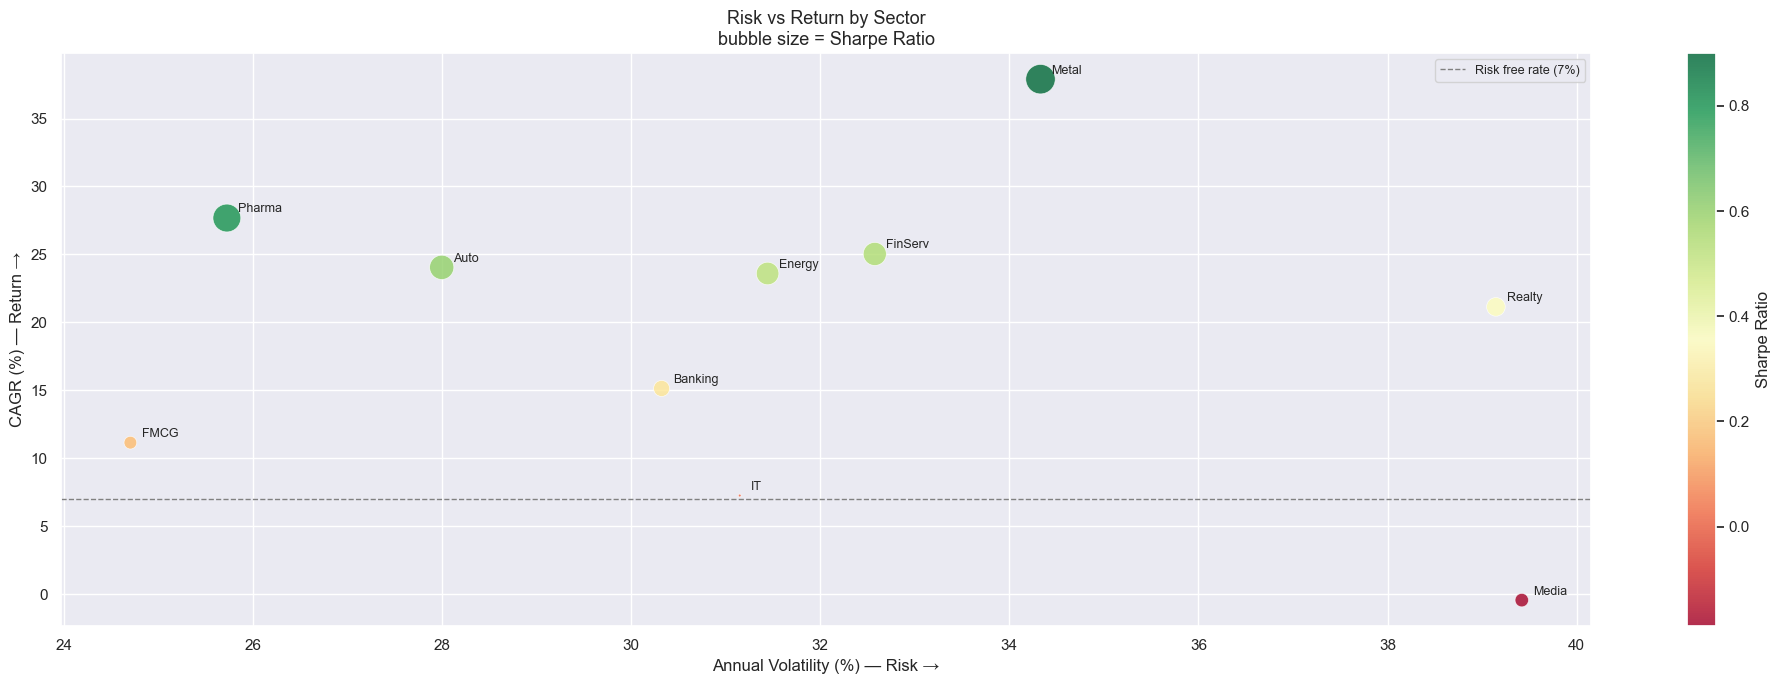

In [47]:
fig, ax = plt.subplots(figsize=(20, 7))

# scatter plot: x = risk (volatility), y = reward (CAGR)
scatter = ax.scatter(
    summary["Ann_Volatility"] * 100,  # x axis: annual volatility %
    summary["CAGR"] * 100,            # y axis: CAGR %
    s=summary["Sharpe_Ratio"].abs() * 500,  # bubble size = Sharpe ratio
    c=summary["Sharpe_Ratio"],        # bubble color = Sharpe ratio
    cmap="RdYlGn",                    # red = bad Sharpe, green = good
    alpha=0.8,
    edgecolors="white",
    linewidth=0.5
)

# labeling
for _, row in summary.iterrows():
    ax.annotate(
        row["Sector"],
        xy=(row["Ann_Volatility"] * 100, row["CAGR"] * 100),
        xytext=(8, 4),                
        textcoords="offset points",  
        fontsize=9
    )

# risk free rate horizontal line
ax.axhline(
    y=7,
    color="gray",
    linestyle="--",
    linewidth=1,
    label="Risk free rate (7%)"
)

plt.colorbar(scatter, label="Sharpe Ratio")
ax.set_xlabel("Annual Volatility (%) — Risk →")
ax.set_ylabel("CAGR (%) — Return →")
ax.set_title("Risk vs Return by Sector\nbubble size = Sharpe Ratio", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [48]:
# Pivot daily returns into wide format
# rows = dates, columns = sectors, values = average daily return
sector_returns_wide = sector_daily.pivot(
    index="Date",
    columns="Sector",
    values="Daily_Return"        
)

# Compute correlation matrix vis .corr() pearson
corr_matrix = sector_returns_wide.corr()

corr_matrix.round(2)

Sector,Auto,Banking,Energy,FMCG,FinServ,IT,Media,Metal,Pharma,Realty
Sector,,,,,,,,,,
Auto,1.00,0.71,0.70,0.60,0.76,0.56,0.65,0.70,0.63,0.70
Banking,0.71,1.00,0.76,0.47,0.79,0.48,0.67,0.72,0.53,0.70
Energy,0.70,0.76,1.00,0.47,0.74,0.49,0.67,0.79,0.56,0.69
FMCG,0.60,0.47,0.47,1.00,0.55,0.44,0.51,0.47,0.49,0.53
FinServ,0.76,0.79,0.74,0.55,1.00,0.56,0.67,0.73,0.59,0.75
IT,0.56,0.48,0.49,0.44,0.56,1.00,0.53,0.53,0.51,0.57
Media,0.65,0.67,0.67,0.51,0.67,0.53,1.00,0.67,0.52,0.72
Metal,0.70,0.72,0.79,0.47,0.73,0.53,0.67,1.00,0.59,0.70
Pharma,0.63,0.53,0.56,0.49,0.59,0.51,0.52,0.59,1.00,0.56


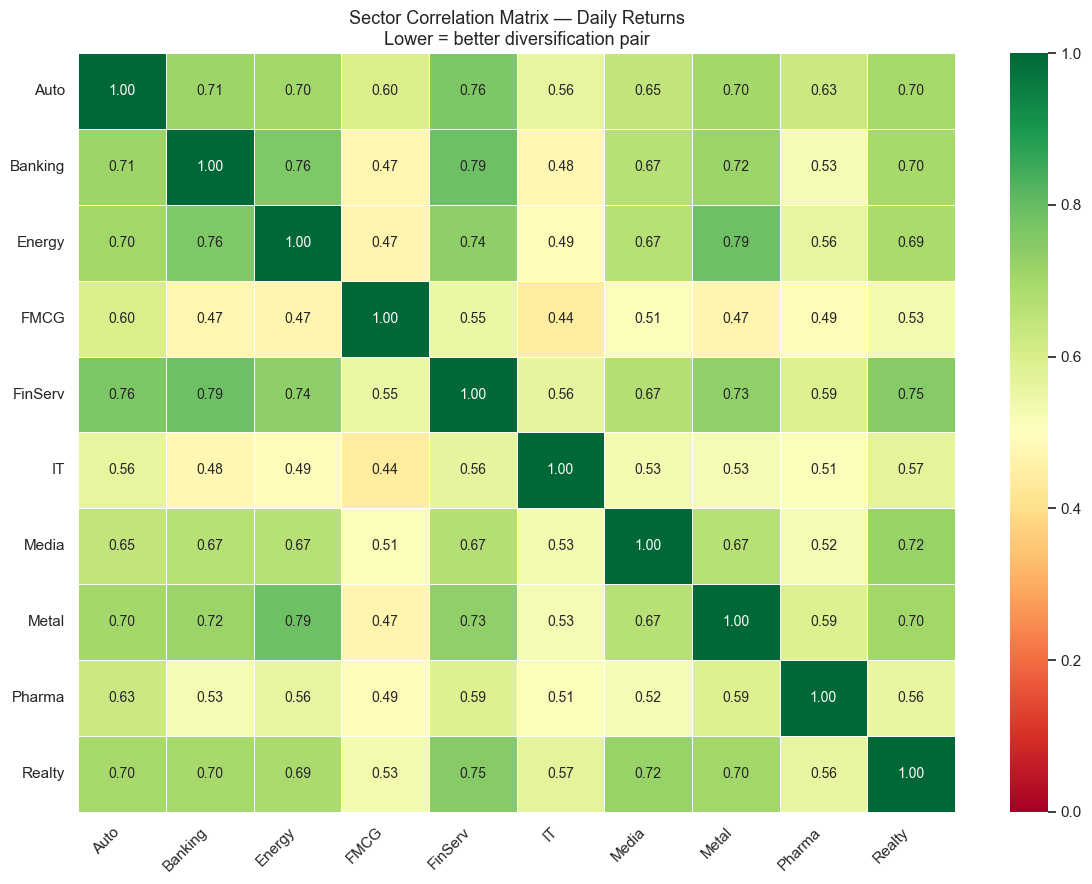

In [49]:
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,           # show correlation numbers inside each cell
    fmt=".2f",            # format to 2 decimal places
    cmap="RdYlGn",        # red = low correlation, green = high
    vmin=0,               # anchor scale at 0
    vmax=1,               # anchor scale at 1
    center=0.5,           # center colormap at 0.5
    linewidths=0.5,        # thin white lines between cells
    linecolor="white",
    ax=ax,
    annot_kws={"size": 10}
)

ax.set_title("Sector Correlation Matrix — Daily Returns\nLower = better diversification pair", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
# Lets build covariance matrix from correlation matrix
# cov(i,j) = corr(i,j) × vol_i × vol_j
# this converts dimensionless correlations back into actual variance units

vols_series = sector_vol_summary.set_index("Sector")["Ann_Volatility"]

# align volatilities to match correlation matrix column order
vols_aligned = vols_series[corr_matrix.columns].values  # shape (10,)

# outer product gives vol_i × vol_j for every pair
vol_outer = np.outer(vols_aligned, vols_aligned)         # shape (10,10)

# element-wise multiply with correlation matrix
cov_matrix = corr_matrix.values * vol_outer              # shape (10,10)

print("Covariance matrix diagonal (= variance per sector):")
print(np.diag(cov_matrix).round(4))  # diagonal = vol² for each sector
print("\nSquare root of diagonal (should match Ann_Volatility):")
print(np.sqrt(np.diag(cov_matrix)).round(4))  # sanity check

Covariance matrix diagonal (= variance per sector):
[0.0784 0.0919 0.0989 0.061  0.1061 0.097  0.1554 0.1179 0.0662 0.1532]

Square root of diagonal (should match Ann_Volatility):
[0.28   0.3032 0.3144 0.247  0.3258 0.3115 0.3942 0.3433 0.2572 0.3915]


In [51]:
expected = vols_aligned
actual   = np.sqrt(np.diag(cov_matrix))

print(f"{'Sector':<12} {'Expected':>10} {'Actual':>10} {'Match':>8}")
print("-" * 44)
for sector, exp, act in zip(corr_matrix.columns, expected, actual):
    match = "Yes" if abs(exp - act) < 1e-6 else "No"
    print(f"{sector:<12} {exp:>10.4f} {act:>10.4f} {match:>8}")


Sector         Expected     Actual    Match
--------------------------------------------
Auto             0.2800     0.2800      Yes
Banking          0.3032     0.3032      Yes
Energy           0.3144     0.3144      Yes
FMCG             0.2470     0.2470      Yes
FinServ          0.3258     0.3258      Yes
IT               0.3115     0.3115      Yes
Media            0.3942     0.3942      Yes
Metal            0.3433     0.3433      Yes
Pharma           0.2572     0.2572      Yes
Realty           0.3915     0.3915      Yes


In [52]:
n_portfolios = 5000
cagrs_aligned = summary.set_index("Sector")["CAGR"][corr_matrix.columns].values

port_vols, port_returns, port_sharpes = [], [], []

for _ in range(n_portfolios):
    weights = np.random.dirichlet(np.ones(len(corr_matrix)))
    
    # correct portfolio return — still weighted average
    p_return = np.dot(weights, cagrs_aligned)
    
    # correct portfolio volatility — uses full covariance matrix
    # w.T @ cov @ w gives portfolio variance
    # sqrt converts variance to volatility
    p_vol = np.sqrt(weights @ cov_matrix @ weights)
    
    # sharpe per portfolio
    p_sharpe = (p_return - 0.07) / p_vol
    
    port_returns.append(p_return * 100)
    port_vols.append(p_vol * 100)
    port_sharpes.append(p_sharpe)

port_returns = np.array(port_returns)
port_vols    = np.array(port_vols)
port_sharpes = np.array(port_sharpes)

print(f"Portfolio vol range:    {port_vols.min():.2f}% — {port_vols.max():.2f}%")
print(f"Portfolio return range: {port_returns.min():.2f}% — {port_returns.max():.2f}%")
print(f"Best Sharpe portfolio:  {port_sharpes.max():.3f}")

Portfolio vol range:    21.98% — 33.34%
Portfolio return range: 6.01% — 30.93%
Best Sharpe portfolio:  0.812


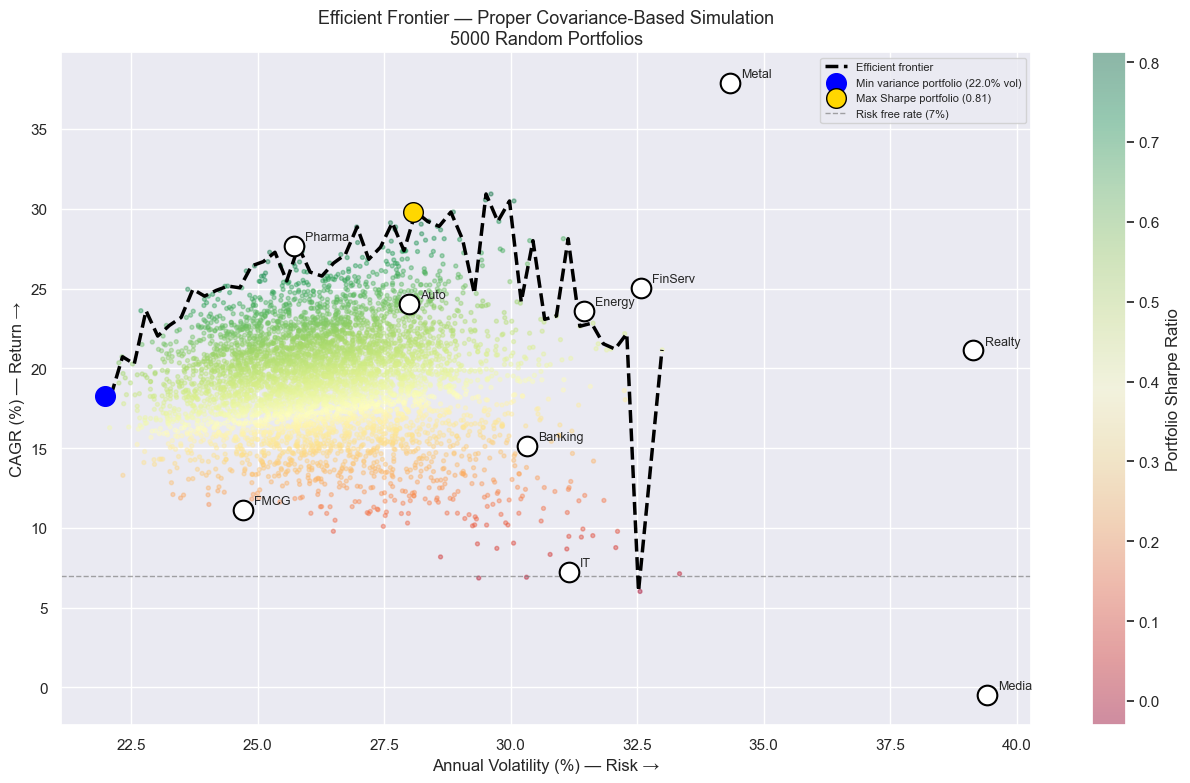

In [53]:
fig, ax = plt.subplots(figsize=(13, 8))

# portfolio cloud — colored by sharpe ratio
cloud = ax.scatter(
    port_vols, port_returns,
    c=port_sharpes,           # color each dot by its sharpe
    cmap="RdYlGn",
    s=8,
    alpha=0.4,
    zorder=1
)
plt.colorbar(cloud, ax=ax, label="Portfolio Sharpe Ratio")

# efficient frontier — top edge of the cloud
# for each volatility bucket, find the highest return portfolio
# that's the efficient frontier point for that risk level
vol_buckets = np.linspace(port_vols.min(), port_vols.max(), 50)
frontier_vols, frontier_returns = [], []

for i in range(len(vol_buckets) - 1):
    mask = (port_vols >= vol_buckets[i]) & (port_vols < vol_buckets[i+1])
    if mask.sum() > 0:
        best_return = port_returns[mask].max()  # highest return in this vol bucket
        frontier_vols.append((vol_buckets[i] + vol_buckets[i+1]) / 2)
        frontier_returns.append(best_return)

ax.plot(
    frontier_vols, frontier_returns,
    color="black",
    linewidth=2.5,
    linestyle="--",
    zorder=4,
    label="Efficient frontier"
)

# sector bubbles on top
sector_scatter = ax.scatter(
    summary["Ann_Volatility"] * 100,
    summary["CAGR"] * 100,
    s=200,
    c="white",
    edgecolors="black",
    linewidth=1.5,
    zorder=5
)

for _, row in summary.iterrows():
    ax.annotate(
        row["Sector"],
        xy=(row["Ann_Volatility"] * 100, row["CAGR"] * 100),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=9,
        zorder=6
    )

# minimum variance portfolio — leftmost point of frontier
min_vol_idx = np.argmin(port_vols)
ax.scatter(
    port_vols[min_vol_idx], port_returns[min_vol_idx],
    s=200, color="blue", zorder=6, label=f"Min variance portfolio ({port_vols[min_vol_idx]:.1f}% vol)"
)

# maximum sharpe portfolio — tangency point
max_sharpe_idx = np.argmax(port_sharpes)
ax.scatter(
    port_vols[max_sharpe_idx], port_returns[max_sharpe_idx],
    s=200, color="gold", edgecolors="black", linewidth=1, zorder=6,
    label=f"Max Sharpe portfolio ({port_sharpes.max():.2f})"
)

ax.axhline(y=7, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Risk free rate (7%)")

ax.set_xlabel("Annual Volatility (%) — Risk →")
ax.set_ylabel("CAGR (%) — Return →")
ax.set_title("Efficient Frontier — Proper Covariance-Based Simulation\n5000 Random Portfolios", fontsize=13)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

In [54]:
# save all analysis outputs
master_df.to_csv("master_clean.csv", index=False)
sector_returns.to_csv("sector_returns.csv", index=False)
summary.to_csv("sector_summary.csv", index=False)
sector_daily.to_csv("sector_daily_cumulative.csv", index=False)
corr_matrix.to_csv("correlation_matrix.csv")

print("All files saved!")
print("Files ready for PostgreSQL + Power BI:")
for f in ["master_clean.csv","sector_returns.csv","sector_summary.csv","sector_daily_cumulative.csv","correlation_matrix.csv"]:
    print(f"  Saved: {f}")

All files saved!
Files ready for PostgreSQL + Power BI:
  Saved: master_clean.csv
  Saved: sector_returns.csv
  Saved: sector_summary.csv
  Saved: sector_daily_cumulative.csv
  Saved: correlation_matrix.csv


In [55]:


# fetch NIFTY 50 index data
nifty = yf.download("^NSEI", period="3y", auto_adjust=True, progress=False)
nifty = nifty[["Close"]].reset_index()
nifty.columns = ["Date", "Nifty_Close"]

# compute NIFTY cumulative return
nifty = nifty.sort_values("Date")
nifty["Nifty_Daily_Return"] = nifty["Nifty_Close"].pct_change()
nifty["Nifty_Cumulative_Return"] = (
    (1 + nifty["Nifty_Daily_Return"]).cumprod() - 1
) * 100

print(nifty.tail())
print(nifty.shape)

          Date   Nifty_Close  Nifty_Daily_Return  Nifty_Cumulative_Return
734 2026-05-06  24330.949219            0.012406                32.848561
735 2026-05-07  24326.650391           -0.000177                32.825089
736 2026-05-08  24176.150391           -0.006187                32.003349
737 2026-05-11  23815.849609           -0.014903                30.036083
738 2026-05-12  23379.550781           -0.018320                27.653863
(739, 4)


In [56]:
np.random.seed(42)  # fix seed so results are reproducible

n_portfolios = 5000
cagrs_aligned = summary.set_index("Sector")["CAGR"][corr_matrix.columns].values

port_vols2, port_returns2, port_sharpes2, port_weights2 = [], [], [], []

for _ in range(n_portfolios):
    weights = np.random.dirichlet(np.ones(len(corr_matrix)))
    p_return = np.dot(weights, cagrs_aligned)
    p_vol    = np.sqrt(weights @ cov_matrix @ weights)
    p_sharpe = (p_return - 0.07) / p_vol

    port_returns2.append(p_return * 100)
    port_vols2.append(p_vol * 100)
    port_sharpes2.append(p_sharpe)
    port_weights2.append(weights)        # save weights this time

port_returns2  = np.array(port_returns2)
port_vols2     = np.array(port_vols2)
port_sharpes2  = np.array(port_sharpes2)
port_weights2  = np.array(port_weights2)  # shape (5000, 10)

# extract max sharpe portfolio weights
max_sharpe_idx = np.argmax(port_sharpes2)
optimal_weights = port_weights2[max_sharpe_idx]

# show weights per sector
weight_df = pd.DataFrame({
    "Sector":  corr_matrix.columns,
    "Weight":  optimal_weights
}).sort_values("Weight", ascending=False)

print(weight_df.to_string(index=False))
print(f"\nWeights sum to: {optimal_weights.sum():.4f}")
print(f"Max Sharpe:     {port_sharpes2[max_sharpe_idx]:.3f}")
print(f"Expected CAGR:  {port_returns2[max_sharpe_idx]:.2f}%")
print(f"Expected Vol:   {port_vols2[max_sharpe_idx]:.2f}%")

 Sector   Weight
 Pharma 0.396023
  Metal 0.277861
 Energy 0.100261
FinServ 0.082051
   Auto 0.063643
 Realty 0.037174
Banking 0.020672
     IT 0.017846
  Media 0.003927
   FMCG 0.000541

Weights sum to: 1.0000
Max Sharpe:     0.845
Expected CAGR:  28.67%
Expected Vol:   25.65%


In [57]:
# apply optimal weights to sector daily returns
sector_daily_wide = sector_daily.pivot(
    index="Date",
    columns="Sector",
    values="Daily_Return"
).fillna(0)

# align columns to match weight order
sector_daily_wide = sector_daily_wide[corr_matrix.columns]

# portfolio daily return = weighted sum of sector returns
portfolio_daily = sector_daily_wide @ optimal_weights  # matrix multiply

# build portfolio DataFrame
portfolio_df = pd.DataFrame({
    "Date": sector_daily_wide.index,
    "Portfolio_Daily_Return": portfolio_daily.values
}).sort_values("Date").reset_index(drop=True)

# cumulative return
portfolio_df["Portfolio_Cumulative_Return"] = (
    (1 + portfolio_df["Portfolio_Daily_Return"]).cumprod() - 1
) * 100

# merge with NIFTY
# align dates — only keep dates present in both
benchmark_df = nifty[["Date", "Nifty_Cumulative_Return"]].copy()

comparison_df = portfolio_df.merge(benchmark_df, on="Date", how="inner")

print(comparison_df.tail())
print(comparison_df.shape)
print(f"\nFinal Portfolio Return: {comparison_df['Portfolio_Cumulative_Return'].iloc[-1]:.2f}%")
print(f"Final NIFTY Return:     {comparison_df['Nifty_Cumulative_Return'].iloc[-1]:.2f}%")
print(f"Alpha (outperformance): {comparison_df['Portfolio_Cumulative_Return'].iloc[-1] - comparison_df['Nifty_Cumulative_Return'].iloc[-1]:.2f}%")

          Date  Portfolio_Daily_Return  Portfolio_Cumulative_Return  \
734 2026-05-06                0.016721                   125.458595   
735 2026-05-07                0.006329                   126.885564   
736 2026-05-08               -0.003222                   126.154537   
737 2026-05-11               -0.004420                   125.154847   
738 2026-05-12               -0.018968                   120.884105   

     Nifty_Cumulative_Return  
734                32.848561  
735                32.825089  
736                32.003349  
737                30.036083  
738                27.653863  
(739, 4)

Final Portfolio Return: 120.88%
Final NIFTY Return:     27.65%
Alpha (outperformance): 93.23%


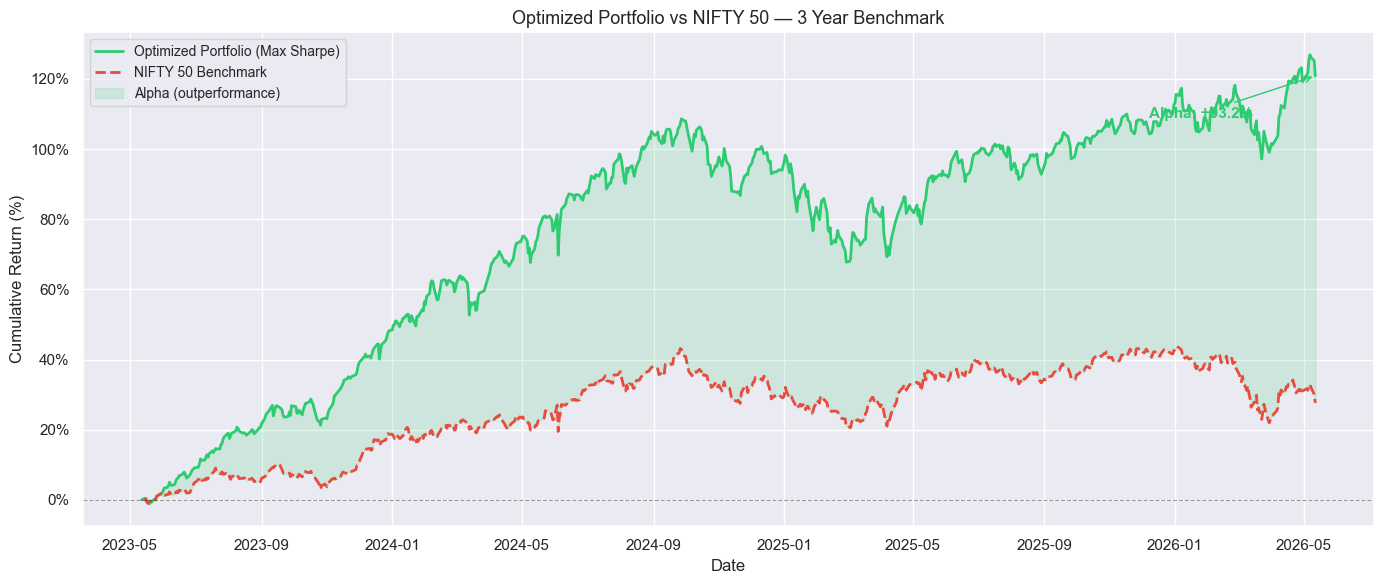

In [58]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    comparison_df["Date"],
    comparison_df["Portfolio_Cumulative_Return"],
    label="Optimized Portfolio (Max Sharpe)",
    color="#2ecc71",
    linewidth=2
)

ax.plot(
    comparison_df["Date"],
    comparison_df["Nifty_Cumulative_Return"],
    label="NIFTY 50 Benchmark",
    color="#e74c3c",
    linewidth=2,
    linestyle="--"
)

# shade the gap between portfolio and NIFTY — visual alpha
ax.fill_between(
    comparison_df["Date"],
    comparison_df["Portfolio_Cumulative_Return"],
    comparison_df["Nifty_Cumulative_Return"],
    alpha=0.15,
    color="#2ecc71",
    label="Alpha (outperformance)"
)

ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--", alpha=0.4)

# annotate final alpha
ax.annotate(
    f"Alpha: +93.2%",
    xy=(comparison_df["Date"].iloc[-1], comparison_df["Portfolio_Cumulative_Return"].iloc[-1]),
    xytext=(-120, -30),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold",
    color="#2ecc71",
    arrowprops=dict(arrowstyle="->", color="#2ecc71")
)

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.set_title("Optimized Portfolio vs NIFTY 50 — 3 Year Benchmark", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [59]:
# save to CSV
comparison_df.to_csv("portfolio_vs_nifty.csv", index=False)
weight_df.to_csv("portfolio_weights.csv", index=False)

print("Saved!")
print(f"  portfolio_vs_nifty.csv: {comparison_df.shape}")
print(f"  portfolio_weights.csv:  {weight_df.shape}")

Saved!
  portfolio_vs_nifty.csv: (739, 4)
  portfolio_weights.csv:  (10, 2)
